# NMR FID — Analog Discovery 2

**Wiring**
```
W1 (Yellow)       --+---> TX Amp (2-5 MHz) ---> RF Coil
                    |
Scope 1+ (Orange) <-- T-connector on W1 line    (TX monitor)
Scope 2+ (Blue)   <-- RX Amp <-- RF Coil        (FID signal)
GND (Black)       --- common ground
```
Use a T/R switch or separate TX/RX coils to protect the RX amp during the pulse.

The RF pulse is generated as **explicit sample data** uploaded to W1 as a custom waveform.
This gives full control over carrier frequency, amplitude, width, and envelope shape.

Pulse  : gaussian  f0=3.4068 MHz  1.0 Vp  50 µs  (5000 samples)
Record : 100 MSPS  5 ms  (500000 samples)


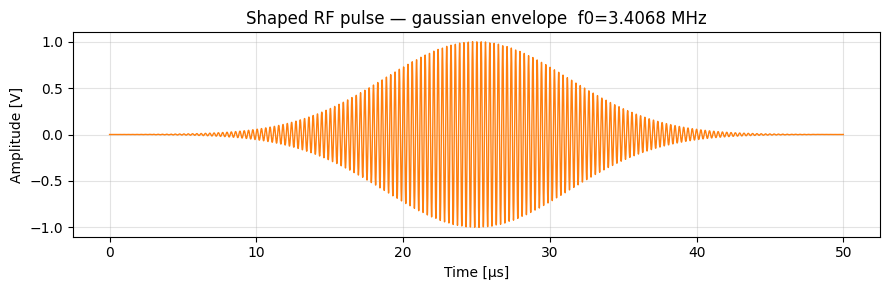

In [40]:
import dwfpy as dwf
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert
import threading, time

# ── Pulse parameters ──────────────────────────────────────────────
F0_HZ        = 3.406772e6    # carrier / Larmor frequency [Hz]
PULSE_SHAPE  = 'gaussian'    # 'gaussian'  or  'trapezoid'
PULSE_V      = 1.0      # was 1.0V — go back to 3V for enough flip angle
PULSE_US     = 50.0     # was 100µs — shorter hard pulse is more broadband

# Gaussian: sigma = PULSE_US / SIGMA_FACTOR  (larger → narrower)
SIGMA_FACTOR = 8.0

# Trapezoid: fraction of PULSE_US used for each rise / fall edge
RISE_FRAC    = 0.10          # 10 % rise, 10 % fall

# ── Acquisition parameters ────────────────────────────────────────
RECORD_S     = 5e-3     # was 0.1s — FID is dead after ~10ms, USB can't sustain 100ms
FS           = 100e6          # sample rate [Hz]  (10 MSPS fits USB bandwidth)
N            = int(FS * RECORD_S)
N_AVG        = 8             # signal averages
TR           = 2.0           # repetition time [s]  (>= 3*T1)

# ── Build shaped RF pulse ─────────────────────────────────────────
# The AD2 custom waveform buffer is normalised to [-1, +1].
# Actual amplitude is set by PULSE_V in wavegen.setup().

N_PULSE = int(FS * PULSE_US * 1e-6)     # samples in pulse window
t_pulse = np.arange(N_PULSE) / FS       # time axis [s]
carrier = np.sin(2 * np.pi * F0_HZ * t_pulse)

if PULSE_SHAPE == 'gaussian':
    sigma    = (PULSE_US * 1e-6) / SIGMA_FACTOR
    t_mid    = (PULSE_US * 1e-6) / 2
    envelope = np.exp(-0.5 * ((t_pulse - t_mid) / sigma) ** 2)
elif PULSE_SHAPE == 'trapezoid':
    n_edge   = max(1, int(RISE_FRAC * N_PULSE))
    envelope = np.ones(N_PULSE)
    envelope[:n_edge]  = np.linspace(0, 1, n_edge)
    envelope[-n_edge:] = np.linspace(1, 0, n_edge)
else:
    raise ValueError(f'Unknown PULSE_SHAPE: {PULSE_SHAPE}')

pulse_samples = envelope * carrier          # shaped RF burst, peak ~1
pulse_samples /= np.max(np.abs(pulse_samples))  # normalise to ±1

print(f'Pulse  : {PULSE_SHAPE}  f0={F0_HZ/1e6:.4f} MHz  '
      f'{PULSE_V} Vp  {PULSE_US:.0f} µs  ({N_PULSE} samples)')
print(f'Record : {FS/1e6:.0f} MSPS  {RECORD_S*1e3:.0f} ms  ({N} samples)')

# Quick pulse preview
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(t_pulse * 1e6, pulse_samples * PULSE_V, color='tab:orange', lw=1.0)
ax.set(xlabel='Time [µs]', ylabel='Amplitude [V]',
       title=f'Shaped RF pulse — {PULSE_SHAPE} envelope  f0={F0_HZ/1e6:.4f} MHz')
ax.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()

In [41]:
# ── Run experiment ────────────────────────────────────────────────
import ctypes
import dwfpy.bindings as dwfb

def acquire_once(scope, wavegen):
    result, errors = {}, []
    def worker():
        try:
            recorder = scope.record(sample_rate=FS, length=RECORD_S,
                                    configure=True, start=True)
            result['ch0'] = np.array(recorder.channels[0].data_samples)
            result['ch1'] = np.array(recorder.channels[1].data_samples)
        except Exception as e:
            errors.append(e)
    t = threading.Thread(target=worker, daemon=True)
    t.start()
    time.sleep(0.05)               # wait for scope to reach Armed state
    wavegen.configure(start=True)  # fire pulse
    t.join(timeout=RECORD_S + 10)
    if errors: raise errors[0]
    return result['ch0'], result['ch1']

with dwf.AnalogDiscovery2() as device:
    print(f'Connected: {device.name}  SN: {device.serial_number}')

    scope   = device.analog_input
    wavegen = device.analog_output[0]

    # Scope channels
    scope[0].setup(range=5.0, offset=0.0, coupling='dc')   # TX monitor
    scope[1].setup(range=0.5, offset=0.0, coupling='dc')   # FID / RX
    # Cell 2 — lower trigger threshold to match 3V pulse through T-connector:
    scope.setup_edge_trigger(mode='normal', channel=0, slope='rising',
                            level=0.1,       # was 0.5V — T-connector halves voltage
                            hysteresis=0.02)
    # Upload custom waveform buffer via low-level binding, then configure channel.
    # dwfpy binding convention: FDwfAnalogOutNodeDataSet → dwf_analog_out_node_data_set
    # ANALOG_OUT_NODE_CARRIER = 0 (carrier node)
    pulse_freq = 1.0 / (PULSE_US * 1e-6)   # replay rate: one buffer = one pulse

    buf = pulse_samples.astype(np.float64)
    ptr = buf.ctypes.data_as(ctypes.POINTER(ctypes.c_double))

    dwfb.dwf_analog_out_node_data_set(
        device.handle,
        0,
        dwfb.ANALOG_OUT_NODE_CARRIER,
        ptr,
        len(buf)
    )
    wavegen.setup(function='custom', frequency=pulse_freq,
                  amplitude=PULSE_V, offset=0.0, start=False)
    wavegen.run_duration = PULSE_US * 1e-6
    wavegen.repeat_count = 1

    # Averaged acquisition
    fid_sum, tx_ref = np.zeros(N), None
    for i in range(N_AVG):
        ch0, ch1 = acquire_once(scope, wavegen)
        ch0 = np.resize(ch0, N)
        ch1 = np.resize(ch1, N)
        fid_sum += ch1
        if tx_ref is None: tx_ref = ch0.copy()
        print(f'  shot {i+1}/{N_AVG}  RX peak = {np.abs(ch1).max()*1e3:.2f} mV')
        if i < N_AVG - 1: time.sleep(TR)

print('Device closed.')
fid = fid_sum / N_AVG
t_s = np.arange(N) / FS

Connected: Analog Discovery 2  SN: 210321A80279
  shot 1/8  RX peak = 963.25 mV
  shot 2/8  RX peak = 831.81 mV
  shot 3/8  RX peak = 906.38 mV
  shot 4/8  RX peak = 740.31 mV
  shot 5/8  RX peak = 779.46 mV
  shot 6/8  RX peak = 837.26 mV
  shot 7/8  RX peak = 896.85 mV
  shot 8/8  RX peak = 875.06 mV
Device closed.


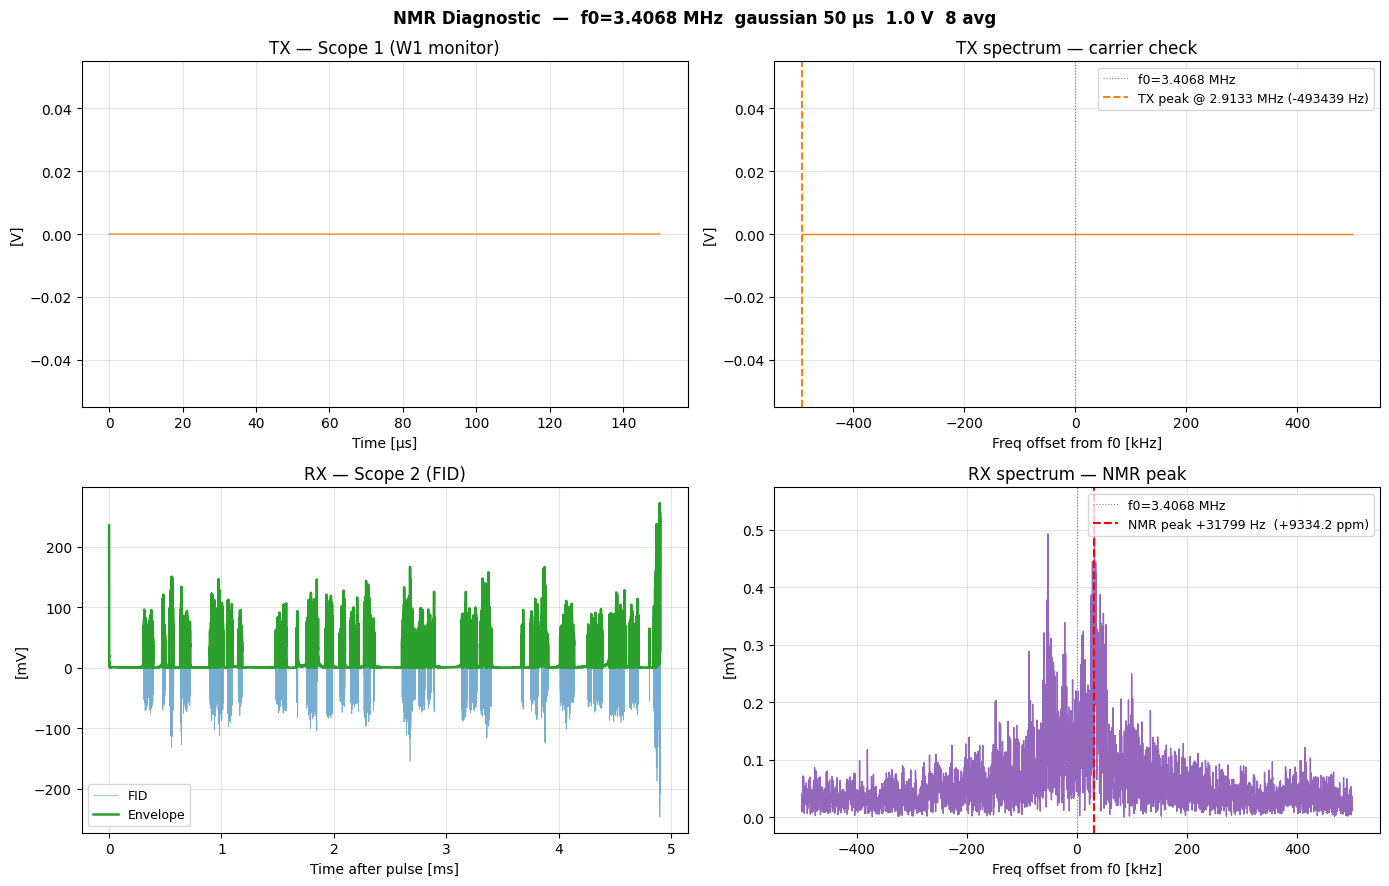

TX carrier  : 2.913333 MHz  (offset -493438.7 Hz from f0)
NMR peak    : 3.438571 MHz  (offset +31799.4 Hz, +9334.18 ppm)
Set F0_HZ = 3438571.43  to put NMR peak at 0 Hz offset next run


In [43]:
# ── Diagnostic visualisation ──────────────────────────────────────
# 4-panel: TX time | TX FFT | RX time | RX FFT

def rfft_db(signal, fs, ref=1.0):
    """Return (freqs_Hz, magnitude) using a Hanning window."""
    n      = len(signal)
    win    = np.hanning(n)
    spec   = np.fft.rfft(signal * win)
    mag    = 2 * np.abs(spec) / win.sum()
    freqs  = np.fft.rfftfreq(n, d=1/fs)
    return freqs, mag

# TX: first PULSE_US*3 µs
n_tx   = int(FS * PULSE_US * 3e-6)
t_tx   = t_s[:n_tx] * 1e6
sig_tx = tx_ref[:n_tx]

# RX: skip dead-time after pulse
DEAD   = int(FS * PULSE_US * 2e-6)     # skip 2× pulse width
t_fid  = (t_s[DEAD:] - t_s[DEAD]) * 1e3
sig_rx = fid[DEAD:]
env_rx = np.abs(hilbert(sig_rx))

# FFTs (±500 kHz zoom around f0)
BW = 500e3
f_tx, m_tx = rfft_db(sig_tx, FS)
f_rx, m_rx = rfft_db(sig_rx, FS)
mk_tx = np.abs(f_tx - F0_HZ) < BW
mk_rx = np.abs(f_rx - F0_HZ) < BW

pk_tx_f  = f_tx[mk_tx][np.argmax(m_tx[mk_tx])]
pk_rx_f  = f_rx[mk_rx][np.argmax(m_rx[mk_rx])]
offset   = pk_rx_f - F0_HZ

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle(
    f'NMR Diagnostic  —  f0={F0_HZ/1e6:.4f} MHz  '
    f'{PULSE_SHAPE} {PULSE_US:.0f} µs  {PULSE_V} V  {N_AVG} avg',
    fontweight='bold', fontsize=12)

# TX time
ax = axes[0, 0]
ax.plot(t_tx, sig_tx, color='tab:orange', lw=0.9)
ax.set(xlabel='Time [µs]', ylabel='[V]',
       title='TX — Scope 1 (W1 monitor)')

# TX FFT
ax = axes[0, 1]
ax.plot((f_tx[mk_tx] - F0_HZ)/1e3, m_tx[mk_tx], color='tab:orange', lw=1.0)
ax.axvline(0, color='gray', lw=0.8, ls=':', label=f'f0={F0_HZ/1e6:.4f} MHz')
ax.axvline((pk_tx_f - F0_HZ)/1e3, color='tab:orange', lw=1.4, ls='--',
           label=f'TX peak @ {pk_tx_f/1e6:.4f} MHz ({(pk_tx_f-F0_HZ):+.0f} Hz)')
ax.set(xlabel='Freq offset from f0 [kHz]', ylabel='[V]',
       title='TX spectrum — carrier check')
ax.legend(fontsize=9)

# RX time
ax = axes[1, 0]
ax.plot(t_fid, sig_rx*1e3, color='tab:blue',  lw=0.5, alpha=0.6, label='FID')
ax.plot(t_fid, env_rx*1e3, color='tab:green', lw=1.8, label='Envelope')
ax.set(xlabel='Time after pulse [ms]', ylabel='[mV]',
       title='RX — Scope 2 (FID)')
ax.legend(fontsize=9)

# RX FFT
ax = axes[1, 1]
ax.plot((f_rx[mk_rx] - F0_HZ)/1e3, m_rx[mk_rx]*1e3, color='tab:purple', lw=1.0)
ax.axvline(0, color='gray', lw=0.8, ls=':', label=f'f0={F0_HZ/1e6:.4f} MHz')
ax.axvline(offset/1e3, color='red', lw=1.5, ls='--',
           label=f'NMR peak {offset:+.0f} Hz  ({offset/F0_HZ*1e6:+.1f} ppm)')
ax.set(xlabel='Freq offset from f0 [kHz]', ylabel='[mV]',
       title='RX spectrum — NMR peak')
ax.legend(fontsize=9, loc='upper right')   # on all four legend() calls

for ax in axes.flat:
    ax.grid(True, alpha=0.35)

plt.tight_layout()
plt.show()

print(f'TX carrier  : {pk_tx_f/1e6:.6f} MHz  (offset {pk_tx_f-F0_HZ:+.1f} Hz from f0)')
print(f'NMR peak    : {pk_rx_f/1e6:.6f} MHz  (offset {offset:+.1f} Hz, {offset/F0_HZ*1e6:+.2f} ppm)')
print(f'Set F0_HZ = {pk_rx_f:.2f}  to put NMR peak at 0 Hz offset next run')